In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

# 실험

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation + Fine-tuning
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling 양을 맞추는거지 질은 다르다
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma
        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test], generator=torch.Generator().manual_seed(42))
        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }
    return clients, metas, list(cols)

# ------------------------------------------------
# 2) DeepMLP 모델 정의
# ------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------
# 3) Focal Loss (불균형 대응) 학습 난이도 불균형 완화
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

# ------------------------------------------------
# 4) αᵢ 및 FedBN Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)
    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K
    return max(1e-8, frac_k * (H_tilde / logK))

def aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=1.0, theta=0.8, use_fedbn=True):
    if not state_dicts: # 이거 3개가 합이 꼭 1이 되어야 하는지 이것도 한번 알아봐야 하겠다.... Max low 보고 알아봐야함
        return None # 이 값이 달라지면 어떻게 얼마나 달라지는지.... 알아보자 (어떻게 바뀌는지 설명해야함)
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}
    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()
    return global_sd

# ------------------------------------------------
# 5) Local Train (FedProx 적용) 좋았다!
# fedavg를 통해서 집계를 하고 fedprox를 통해서 로컬 학습 안정화
# ------------------------------------------------
def local_train(base_model, dataset, lr, epochs, device, global_params=None, mu=0.0):
    model = copy.deepcopy(base_model).to(device)
    model.train()
    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    global_params = [p.detach().clone() for p in base_model.parameters()] if mu > 0 else None
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            if global_params is not None:
                prox = sum(torch.norm(p - g) ** 2 for p, g in zip(model.parameters(), global_params))
                loss += 0.5 * mu * prox
            loss.backward()
            opt.step()
    return model.state_dict()

def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device, thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device, threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t

# ------------------------------------------------
# 6) Main Loop (연합학습)
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim, hidden_dim=128, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]
        state_dicts, alpha_components = {}, {}

        before_acc = evaluate(global_model, combined_test, device)
        global_params = [p.detach().clone() for p in global_model.parameters()]
        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()
            state_dict = local_train(
                base_model=global_model,
                dataset=ds,
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = state_dict
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        new_global = aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=1.0, theta=0.8, use_fedbn=True)
        if new_global is None:
            continue
        global_model.load_state_dict(new_global)
        after_acc = evaluate(global_model, combined_test, device)
        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}")

    print("\n=== Global Evaluation ===")
    best_t = find_best_threshold(global_model, combined_test, device)
    global_acc, yt, yp = evaluate(global_model, combined_test, device, return_preds=True, threshold=best_t)
    print(f"\nFinal Global Accuracy: {global_acc:.4f}")
    print(classification_report(yt, yp, digits=4))

    print("\n=== Per-Client Fine-tuning ===")
    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_state = local_train(global_model, data["train"], lr=0.0008, epochs=args.ft_epochs, device=device)
        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)
        acc_c, yt_c, yp_c = evaluate(local_model, data["test"], device, threshold=best_t, return_preds=True)
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.6037

=== Round 2 ===
[Round 2] Global Accuracy: 0.6037 → 0.6327

=== Round 3 ===
[Round 3] Global Accuracy: 0.6327 → 0.6297

=== Round 4 ===
[Round 4] Global Accuracy: 0.6297 → 0.6282

=== Round 5 ===
[Round 5] Global Accuracy: 0.6282 → 0.6606

=== Round 6 ===
[Round 6] Global Accuracy: 0.6606 → 0.6595

=== Round 7 ===
[Round 7] Global Accuracy: 0.6595 → 0.6640

=== Round 8 ===
[Round 8] Global Accuracy: 0.6640 → 0.6505

=== Round 9 ===
[Round 9] Global Accuracy: 0.6505 → 0.6723

=== Round 10 ===
[Round 10] Global Accuracy: 0.6723 → 0.6727

=== Round 11 ===
[Round 11] Global Accuracy: 0.6727 → 0.6761

=== Round 12 ===
[Round 12] G

In [ ]:
# 시험용

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Round 1] Global Accuracy: 0.5038 → 0.6007 | ΔW=879.0207

=== Round 2 ===
[Round 2] Global Accuracy: 0.6007 → 0.6105 | ΔW=928.9030

=== Round 3 ===
[Round 3] Global Accuracy: 0.6105 → 0.6248 | ΔW=916.8569

=== Round 4 ===
[Round 4] Global Accuracy: 0.6248 → 0.6225 | ΔW=1083.4070

=== Round 5 ===
[Round 5] Global Accuracy: 0.6225 → 0.6312 | ΔW=1081.3901

=== Round 6 ===
[Round 6] Global Accuracy: 0.6312 → 0.6633 | ΔW=763.6008

=== Round 7 ===
[Round 7] Global Accuracy: 0.6633 → 0.6538 | ΔW=914.1636

=== Round 8 ===
[Round 8] Global Accuracy: 0.6538 → 0.6565 | ΔW=915.5608

=== Round 9 ===
[Round 9] Global Accuracy: 0.6565 → 0.6833 | ΔW=763.8557

=== Round 10 ===
[Round 1

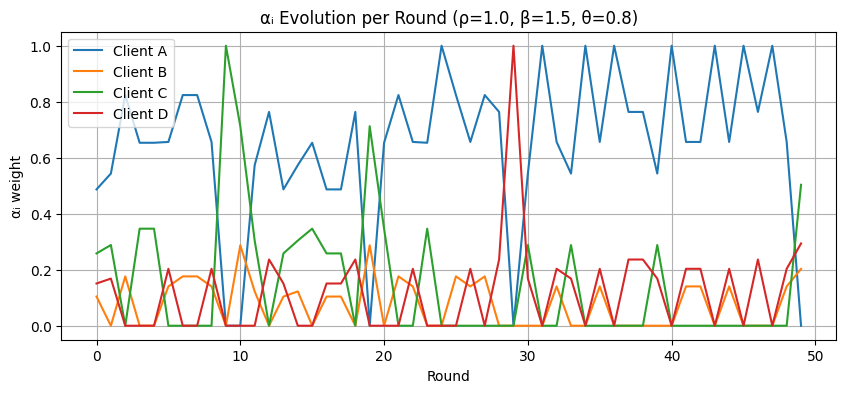

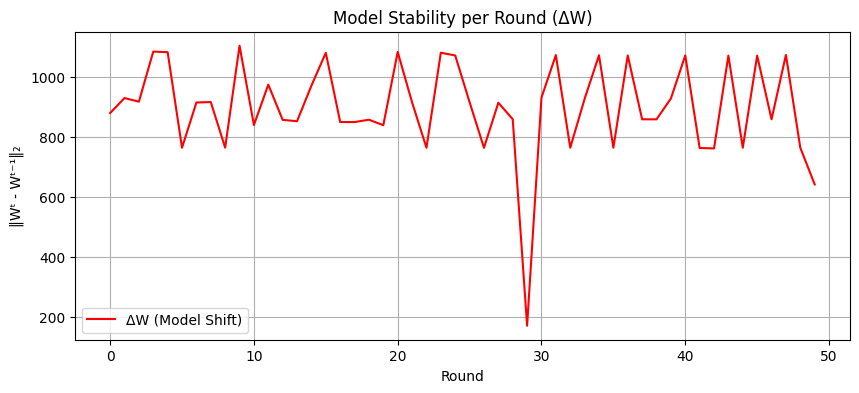

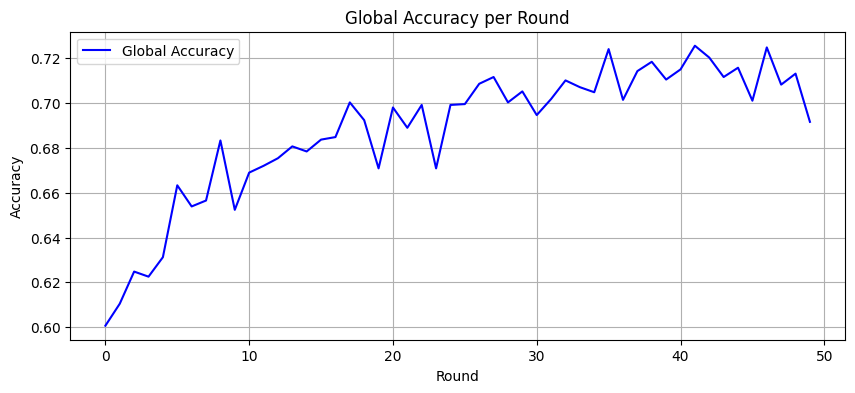


=== Global Evaluation ===
Threshold=0.30, F1=0.7511
Threshold=0.35, F1=0.7647
Threshold=0.40, F1=0.7855
Threshold=0.45, F1=0.8037
Threshold=0.50, F1=0.8049

 Best threshold = 0.50 (F1=0.8049)

Final Global Accuracy: 0.7821
              precision    recall  f1-score   support

           0     0.8596    0.6702    0.7532      1316
           1     0.7331    0.8922    0.8049      1336

    accuracy                         0.7821      2652
   macro avg     0.7964    0.7812    0.7790      2652
weighted avg     0.7959    0.7821    0.7792      2652


=== Per-Client Fine-tuning ===

--- Client A Fine-tuning ---
[Client A] Fine-tuned Accuracy: 0.8102
              precision    recall  f1-score   support

           0     0.9149    0.6837    0.7826       566
           1     0.7479    0.9365    0.8316       567

    accuracy                         0.8102      1133
   macro avg     0.8314    0.8101    0.8071      1133
weighted avg     0.8313    0.8102    0.8071      1133


--- Client B Fine-tu

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation (ρ, β, θ)
# + SMOTE + FocalLoss + FedProx + FedBN + Fine-tuning
# + αᵢ 시각화 + ΔW 시각화
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

# -------------------------------
# 0) 결함 라벨 정의
# -------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# -------------------------------
# 1) 데이터 로드 + SMOTE
# -------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma
        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(allset, [n_train, n_test], generator=torch.Generator().manual_seed(42))
        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }
    return clients, metas, list(cols)

# -------------------------------
# 2) DeepMLP 모델 정의
# -------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# -------------------------------
# 3) Focal Loss
# -------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')
    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

# -------------------------------
# 4) αᵢ 계산 + FedBN Aggregation
# -------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)
    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K
    return max(1e-8, frac_k * (H_tilde / logK))

def aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=1.5, theta=0.8, use_fedbn=True):
    """β=1.5 → 라벨 다양성 반영 강화"""
    if not state_dicts:
        return None
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}
    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()
    return global_sd, alphas

# -------------------------------
# 5) Local Train (FedProx)
# -------------------------------
def local_train(base_model, dataset, lr, epochs, device, global_params=None, mu=0.0):
    model = copy.deepcopy(base_model).to(device)
    model.train()
    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    global_params = [p.detach().clone() for p in base_model.parameters()] if mu > 0 else None
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            if global_params is not None:
                prox = sum(torch.norm(p - g) ** 2 for p, g in zip(model.parameters(), global_params))
                loss += 0.5 * mu * prox
            loss.backward()
            opt.step()
    return model.state_dict()

# -------------------------------
# 6) 평가 및 유틸
# -------------------------------
def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device, thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device, threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t

def compute_model_shift(old_sd, new_sd):
    """ΔW 계산: 전 라운드 대비 파라미터 변화량"""
    shift = 0.0
    for k in old_sd.keys():
        shift += torch.norm(new_sd[k] - old_sd[k]).item()
    return shift

# -------------------------------
# 7) Main Loop (FL + Visualization)
# -------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim, hidden_dim=128, num_classes=2).to(device)

    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    alpha_history = {cid: [] for cid in clients}
    shift_history, acc_history = [], []

    prev_global = copy.deepcopy(global_model.state_dict())

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        state_dicts, alpha_components = {}, {}
        before_acc = evaluate(global_model, combined_test, device)
        global_params = [p.detach().clone() for p in global_model.parameters()]

        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()
            state_dict = local_train(global_model, ds, lr=0.0008, epochs=5, device=device, global_params=global_params, mu=args.mu)
            state_dicts[cid] = state_dict
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        new_global, alphas = aggregate_with_softmax_weights(state_dicts, alpha_components, rho=1.0, beta=1.5, theta=0.8, use_fedbn=True)
        if new_global is None:
            continue

        for cid in clients:
            alpha_history[cid].append(alphas.get(cid, 0))

        delta_w = compute_model_shift(prev_global, new_global)
        shift_history.append(delta_w)
        prev_global = copy.deepcopy(new_global)

        global_model.load_state_dict(new_global)
        after_acc = evaluate(global_model, combined_test, device)
        acc_history.append(after_acc)
        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f} | ΔW={delta_w:.4f}")

    # -------------------------------
    # Visualization
    # -------------------------------
    plt.figure(figsize=(10, 4))
    for cid in alpha_history:
        plt.plot(alpha_history[cid], label=f"Client {cid}")
    plt.title("αᵢ Evolution per Round (ρ=1.0, β=1.5, θ=0.8)")
    plt.xlabel("Round")
    plt.ylabel("αᵢ weight")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(shift_history, label="ΔW (Model Shift)", color="red")
    plt.title("Model Stability per Round (ΔW)")
    plt.xlabel("Round")
    plt.ylabel("‖Wᵗ - Wᵗ⁻¹‖₂")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(acc_history, label="Global Accuracy", color="blue")
    plt.title("Global Accuracy per Round")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    # -------------------------------
    # Final Evaluation
    # -------------------------------
    print("\n=== Global Evaluation ===")
    best_t = find_best_threshold(global_model, combined_test, device)
    global_acc, yt, yp = evaluate(global_model, combined_test, device, return_preds=True, threshold=best_t)
    print(f"\nFinal Global Accuracy: {global_acc:.4f}")
    print(classification_report(yt, yp, digits=4))

    # Fine-tuning
    print("\n=== Per-Client Fine-tuning ===")
    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_state = local_train(global_model, data["train"], lr=0.0008, epochs=args.ft_epochs, device=device)
        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)
        acc_c, yt_c, yp_c = evaluate(local_model, data["test"], device, threshold=best_t, return_preds=True)
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))


# 20251114 mlp 각 라운드 글로벌 정확도 및 각 클라이언트의 로컬 학습 정확도 표시

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation + Fine-tuning
#  - 라운드별 Global Accuracy + 각 참여 클라이언트 Local Accuracy 출력
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
#    (양을 맞추지만, 질/분포는 여전히 클라이언트마다 다를 수 있음)
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨이 없으면 0으로 채우기
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 여러 결함 라벨 → 이진 라벨 (0/1)
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처: 수치형만 사용
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    # X에서 결측 제거된 만큼 y도 맞추기
    y = y[:len(X)]

    # SMOTE로 불균형 보정 (샘플 수 기준)
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 피처만 사용 (모든 클라이언트에 존재하는 열)
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()

        # 클라이언트별 표준화 (mean/std)
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)

        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(
            allset,
            [n_train, n_test],
            generator=torch.Generator().manual_seed(42)
        )

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)

# ------------------------------------------------
# 2) DeepMLP 모델 정의
#    - 입력 → 128 → 128 → 64 → 2 (출력)
#    - 각 hidden에 BN + ReLU + Dropout
# ------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------
# 3) Focal Loss (불균형 대응 - 어려운 샘플에 가중치)
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)          # 잘 맞춘 샘플은 pt↑
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# ------------------------------------------------
# 4) αᵢ 및 FedBN 스타일 Aggregation
#    - αᵢ = softmax( log(n_i^ρ) + log(c_i^β) + log(t_i^θ) )
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    """
    c_i : 레이블 다양성 (엔트로피 + 커버리지 기반)
    """
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    # 엔트로피
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)
    logK = math.log(K + 1e-12)

    # 너무 0에 가까운 엔트로피 방지 (바닥)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    # 최소 min_samples 이상 나타난 클래스 비율
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K

    ci = max(1e-8, frac_k * (H_tilde / logK))
    return ci

def aggregate_with_softmax_weights(state_dicts,
                                   alpha_components,
                                   rho=1.0,
                                   beta=1.0,
                                   theta=0.8,
                                   use_fedbn=True):
    """
    αᵢ softmax 가중 평균 + FedBN 스타일 (BN 파라미터는 기준 클라이언트 것 유지)
    """
    if not state_dicts:
        return None

    # 1) αᵢ를 위한 log-weight 계산
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12) +
            math.log(comp["c_i"] ** beta + 1e-12) +
            math.log(comp["t_i"] ** theta + 1e-12)
        )

    # 2) Softmax
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    # 3) FedBN-style Aggregation
    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        # BN 관련 파라미터는 그대로 유지 (클라이언트 분포 차이 보존)
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = None
            for cid, sd in state_dicts.items():
                w = alphas[cid]
                t = sd[k] * w
                if agg is None:
                    agg = t.clone()
                else:
                    agg += t
            global_sd[k] = agg

    return global_sd

# ------------------------------------------------
# 5) Local Train (FedProx 적용)
#    - FedAvg는 "집계 방식"
#    - FedProx는 "로컬 최적화에 규제항 추가"
# ------------------------------------------------
def local_train(base_model, dataset, lr, epochs, device,
                global_params=None, mu=0.0):
    """
    base_model : 서버 글로벌 모델
    global_params : FedProx용 글로벌 파라미터
    mu : FedProx 강도 (0이면 미적용)

    return: (로컬 학습 후 state_dict, 로컬 데이터에 대한 accuracy)
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    if mu > 0 and global_params is not None:
        global_params = [p.detach().clone() for p in global_params]
    else:
        global_params = None

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx 규제항
            if global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    #  로컬 데이터에 대한 accuracy 계산 (threshold=0.35로 고정)
    local_acc = evaluate(model, dataset, device, threshold=0.35, return_preds=False)

    return model.state_dict(), local_acc

# ------------------------------------------------
# 6) 평가 함수 & 최적 임계값 검색
# ------------------------------------------------
def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    acc = (y_true_np == y_pred_np).mean()

    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device,
                             threshold=t,
                             return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t

# ------------------------------------------------
# 7) Main Loop (연합학습)
#    - 라운드별 Global Accuracy + Local Accuracy 출력
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50)
    parser.add_argument("--mu", type=float, default=0.003)      # FedProx 계수
    parser.add_argument("--ft_epochs", type=int, default=5)     # Fine-tuning epochs
    args, _ = parser.parse_known_args()

    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim, hidden_dim=128, num_classes=2).to(device)

    # 클라이언트 참여 확률
    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}

    # 테스트 데이터: 모든 클라이언트 test 데이터를 concat
    combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

    for rnd in range(1, args.rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # 라운드별 참여 클라이언트 선택
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        state_dicts = {}
        alpha_components = {}
        local_acc_results = {}   #  라운드별 로컬 정확도 기록

        before_acc = evaluate(global_model, combined_test, device)
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 각 클라이언트 로컬 학습
        for cid in selected:
            ds = clients[cid]["train"]
            labels = [int(y) for _, y in ds]
            class_counts = pd.Series(labels).value_counts().to_dict()

            # 로컬 학습 (FedProx + FocalLoss)
            state_dict, local_acc = local_train(
                base_model=global_model,
                dataset=ds,
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = state_dict
            local_acc_results[cid] = local_acc

            # αᵢ 구성요소
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        # 라운드별 로컬 정확도 출력
        local_msg = " | ".join([f"{cid}={local_acc_results[cid]:.4f}" for cid in local_acc_results])
        print(f"[Local Acc] {local_msg}")

        # 글로벌 집계 (αᵢ 가중 FedAvg + FedBN-style BN 처리)
        new_global = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=1.0,
            beta=1.0,
            theta=0.8,
            use_fedbn=True
        )
        if new_global is None:
            continue

        global_model.load_state_dict(new_global)
        after_acc = evaluate(global_model, combined_test, device)
        print(f"[Global Accuracy] {before_acc:.4f} → {after_acc:.4f}")

    # ------------------------------------------------
    # 최종 Global 평가
    # ------------------------------------------------
    print("\n=== Global Evaluation ===")
    best_t = find_best_threshold(global_model, combined_test, device)

    global_acc, yt, yp = evaluate(
        global_model,
        combined_test,
        device,
        return_preds=True,
        threshold=best_t
    )
    print(f"\nFinal Global Accuracy: {global_acc:.4f}")
    print(classification_report(yt, yp, digits=4))

    # ------------------------------------------------
    # Per-Client Fine-tuning (Personalization)
    # ------------------------------------------------
    print("\n=== Per-Client Fine-tuning ===")
    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")

        ft_state, ft_local_acc = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.0008,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0        # Fine-tuning 시에는 FedProx OFF
        )

        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(
            local_model,
            data["test"],
            device,
            threshold=best_t,
            return_preds=True
        )
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
[Local Acc] A=0.6129 | B=0.6794 | D=0.7072
[Global Accuracy] 0.5038 → 0.6060

=== Round 2 ===
[Local Acc] A=0.6189 | B=0.7058 | C=0.6134 | D=0.7288
[Global Accuracy] 0.6060 → 0.6248

=== Round 3 ===
[Local Acc] A=0.6388 | B=0.6992 | C=0.6160 | D=0.7211
[Global Accuracy] 0.6248 → 0.6305

=== Round 4 ===
[Local Acc] A=0.6496 | D=0.7196
[Global Accuracy] 0.6305 → 0.6614

=== Round 5 ===
[Local Acc] A=0.6308 | C=0.6284 | D=0.7227
[Global Accuracy] 0.6614 → 0.6339

=== Round 6 ===
[Local Acc] B=0.7256 | C=0.6207 | D=0.7488
[Global Accuracy] 0.6339 → 0.6380

=== Round 7 ===
[Local Acc] A=0.6439 | B=0.7441
[Global Accuracy] 0.6380 → 0.6440

=== Round 8 ===
[Local Acc] A=0.664

# rho, beta, theta gridsearch로 최적의 조합 찾기

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

############################
# Grid Search over (rho, beta, theta)
############################

>>> Try (rho=0.8, beta=0.8, theta=0.5)

=== Round 1 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 1] Global Accuracy: 0.4962 → 0.6791

=== Round 2 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 2] Global Accuracy: 0.6791 → 0.6916

=== Round 3 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 3] Global Accuracy: 0.6916 → 0.7032

=== Round 4 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 4] Global Accuracy: 0.7032 → 0.7017

=== Round 5 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 5] Global Accuracy: 0.7017 → 0.7206

=== Round 6 (rho=0.8, beta=0.8, theta=0.5) ===
[Round 6] Global Accuracy: 0.7206 → 0.7285

=== Round 

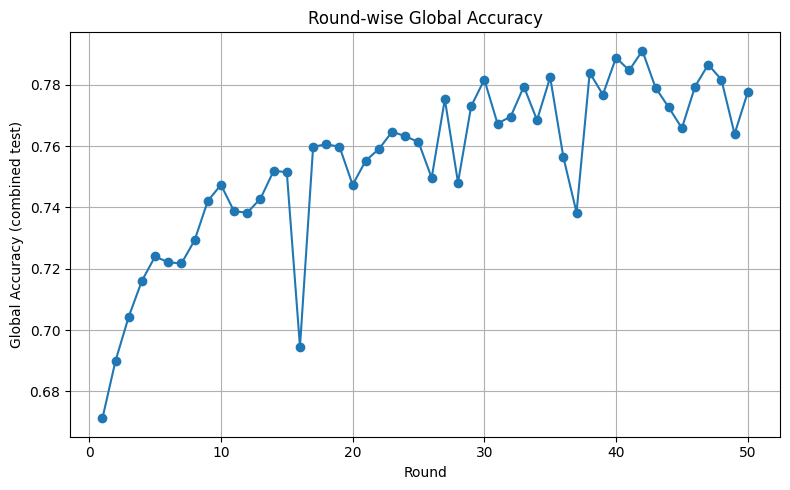

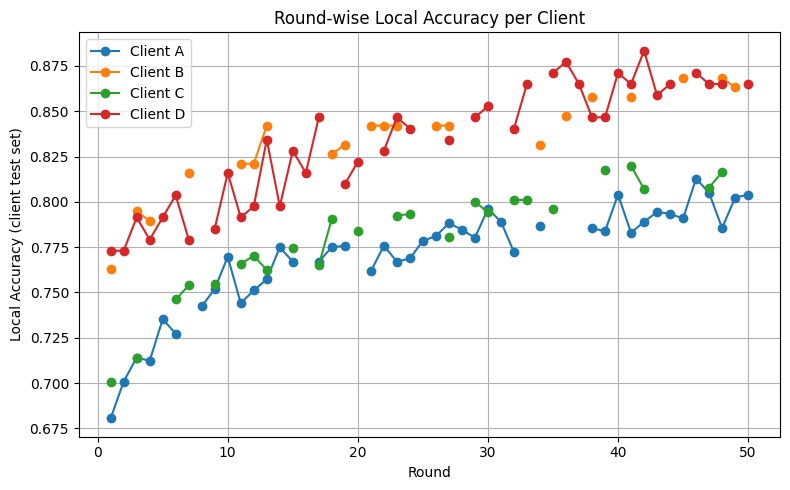

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation (nᵢ, cᵢ, tᵢ)
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation
# + Grid Search over (rho, beta, theta)
# + Per-round Global / Local Accuracy Plot
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# 0) 결함 라벨 정의
# ------------------------------------------------
DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# ------------------------------------------------
# 유틸: 시드 고정
# ------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
#    (양은 맞추지만, 각 클라이언트의 데이터 "질"은 여전히 다름)
# ------------------------------------------------
def oversample_dataset(X, y):
    sm = SMOTE(random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    # 결함 라벨 없으면 0으로 채우기
    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 여러 결함 라벨 → 이진 라벨
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처 생성
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    """
    각 클라이언트별:
      - Excel → (X, y) 로드
      - SMOTE로 내부 클래스 균형 맞춤
      - 공통 피처만 사용
      - 표준화 후 TensorDataset으로 변환
      - 8:2 train/test split
    """
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 공통 피처만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])
    clients, metas = {}, {}

    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)
        allset = TensorDataset(X, y)

        n = len(allset)
        n_train = int(0.8 * n)
        n_test = n - n_train
        tr, te = random_split(
            allset,
            [n_train, n_test],
            generator=torch.Generator().manual_seed(42)
        )

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)


# ------------------------------------------------
# 2) DeepMLP 모델 정의
# ------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            # 1층: input_dim → hidden_dim
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # 2층: hidden_dim → hidden_dim
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # 3층: hidden_dim → hidden_dim//2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            # 출력층: hidden_dim//2 → num_classes(=2)
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ------------------------------------------------
# 3) Focal Loss (불균형 대응: 학습 난이도 기반 re-weighting)
# ------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)   # 기본 CE
        pt = torch.exp(-ce_loss)            # 잘 맞출수록 pt ↑
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# ------------------------------------------------
# 4) αᵢ 구성요소 계산 및 FedBN-style Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    """
    c_i: (1) 유효 클래스 수 비율 × (2) label entropy 정규화 값
    """
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    # 엔트로피
    H = 0.0
    for c in class_counts.values():
        if c > 0:
            p = c / total
            H -= p * math.log(p)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K

    ci = max(1e-8, frac_k * (H_tilde / logK))
    return ci


def aggregate_with_softmax_weights(state_dicts,
                                   alpha_components,
                                   rho=1.0,
                                   beta=1.0,
                                   theta=0.8,
                                   use_fedbn=True):
    """
    αᵢ = softmax( log(nᵢ^ρ) + log(cᵢ^β) + log(tᵢ^θ) )
    FedBN 스타일:
      - BN 관련 파라미터는 기준 클라이언트의 것을 그대로 사용
      - 나머지는 αᵢ 가중 평균
    """
    if not state_dicts:
        return None

    # 1) αᵢ의 logit 계산
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )

    # 2) softmax 정규화 → αᵢ
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(v - max_logit) for cid, v in logits.items()}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    # 3) FedBN + 가중 평균
    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            # BN 계층은 기준 클라이언트(여기서는 첫 번째)의 통계를 그대로 사용
            global_sd[k] = base_sd[k].clone()
        else:
            agg = None
            for cid, sd in state_dicts.items():
                w = alphas[cid]
                t = sd[k] * w
                if agg is None:
                    agg = t.clone()
                else:
                    agg += t
            global_sd[k] = agg

    return global_sd


# ------------------------------------------------
# 5) Local Train (FedProx 적용)
# ------------------------------------------------
def local_train(base_model,
                dataset,
                lr,
                epochs,
                device,
                global_params=None,
                mu=0.0):
    """
    FedProx:
      loss_local + (μ/2) * ||w - w_global||^2
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    if mu > 0 and global_params is not None:
        global_params = [p.detach().clone().to(device) for p in global_params]
    else:
        global_params = None

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx 항 추가
            if global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


def evaluate(model, dataset, device, threshold=0.35, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()
            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    acc = (y_true_np == y_pred_np).mean()

    if return_preds:
        return acc, y_true, y_pred
    return acc


def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.3, 0.51, 0.05)):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device,
                             threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1
    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t, best_f1


# ------------------------------------------------
# 6) 연합학습 실행 함수 (하나의 (rho,beta,theta)에 대해 한 번 돌기)
#    - grid search용: log_round=False 로 가볍게 사용
#    - 최종 학습용: log_round=True 로 라운드별 로그/그래프 저장
# ------------------------------------------------
def run_federated_training(clients,
                           metas,
                           device,
                           input_dim,
                           rho,
                           beta,
                           theta,
                           rounds=30,
                           mu=0.003,
                           ft_epochs=3,
                           log_round=False):
    """
    반환:
      - global_model: 학습된 글로벌 모델
      - combined_test: 전체 테스트 합친 Dataset
      - logs: (log_round=True인 경우) 라운드별 로그
    """
    set_seed(42)

    # 글로벌 모델 초기화
    global_model = DeepMLP(input_dim=input_dim,
                           hidden_dim=128,
                           num_classes=2).to(device)

    # 전체 테스트 데이터
    combined_test = torch.utils.data.ConcatDataset(
        [v["test"] for v in clients.values()]
    )

    # 라운드별 로그 구조
    if log_round:
        round_log = {
            "round": [],
            "global_acc": [],
            "client_acc": {cid: [] for cid in clients.keys()}
        }
    else:
        round_log = None

    # 연합 참여 확률 (고정)
    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}

    for rnd in range(1, rounds + 1):
        print(f"\n=== Round {rnd} (rho={rho}, beta={beta}, theta={theta}) ===")

        # 1) 라운드별 참여 클라이언트 선택
        selected = [cid for cid in clients
                    if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        state_dicts, alpha_components = {}, {}

        # 라운드 시작 시 글로벌 정확도
        before_acc = evaluate(global_model, combined_test, device, threshold=0.5)

        # FedProx용 글로벌 파라미터 백업
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 2) 로컬 학습
        local_acc_this_round = {cid: np.nan for cid in clients.keys()}

        for cid in selected:
            ds_train = clients[cid]["train"]
            ds_test = clients[cid]["test"]

            # label 분포 (c_i 계산용)
            labels = [int(y) for _, y in ds_train]
            class_counts = pd.Series(labels).value_counts().to_dict()

            # 로컬 학습 후 state_dict 얻기
            state_dict = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=mu
            )
            state_dicts[cid] = state_dict

            # 로컬 모델 정확도 (자기 test셋 기준)
            if log_round:
                temp_model = DeepMLP(input_dim=input_dim,
                                     hidden_dim=128,
                                     num_classes=2).to(device)
                temp_model.load_state_dict(state_dict)
                acc_local = evaluate(temp_model, ds_test, device, threshold=0.5)
                local_acc_this_round[cid] = acc_local

            # αᵢ 구성요소
            n_i = math.sqrt(metas[cid]["n_samples"])  # 데이터 수 완화
            c_i = compute_ci(class_counts)           # 레이블 다양성
            t_i = participation_probs[cid]           # 참여 확률 (고정)
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        # 3) 집계 (FedBN + αᵢ softmax 가중 FedAvg)
        new_global = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=rho,
            beta=beta,
            theta=theta,
            use_fedbn=True
        )
        if new_global is None:
            continue

        global_model.load_state_dict(new_global)

        # 4) 라운드 종료 후 글로벌 정확도
        after_acc = evaluate(global_model, combined_test, device, threshold=0.5)
        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}")

        # 로그 저장
        if log_round:
            round_log["round"].append(rnd)
            round_log["global_acc"].append(after_acc)
            for cid in clients.keys():
                round_log["client_acc"][cid].append(local_acc_this_round[cid])

    # 최종 threshold / F1 평가
    print("\n=== Global Evaluation (grid / final run) ===")
    best_t, best_f1 = find_best_threshold(global_model, combined_test, device)

    return global_model, combined_test, best_t, best_f1, round_log


# ------------------------------------------------
# 7) Main: Grid Search + 최종 학습 + 그래프
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds", type=int, default=50, help="최종 학습 라운드 수")
    parser.add_argument("--search_rounds", type=int, default=20, help="grid search용 라운드 수")
    parser.add_argument("--mu", type=float, default=0.003)
    parser.add_argument("--ft_epochs", type=int, default=5)
    args, _ = parser.parse_known_args()

    set_seed(42)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1) 클라이언트 데이터 빌드
    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)
    input_dim = clients["A"]["all"].tensors[0].shape[1]

    # ------------------------------------------------
    # (1) 작은 Grid Search로 (rho, beta, theta) 튜닝
    # ------------------------------------------------
    rho_list = [0.8, 1.0, 1.2]
    beta_list = [0.8, 1.0, 1.3]
    theta_list = [0.5, 0.8, 1.0]

    search_results = []

    print("\n############################")
    print("# Grid Search over (rho, beta, theta)")
    print("############################")

    for rho in rho_list:
        for beta in beta_list:
            for theta in theta_list:
                print(f"\n>>> Try (rho={rho}, beta={beta}, theta={theta})")
                # grid search 시에는 라운드 로그/그래프는 저장하지 않음
                model_g, combined_test, best_t, best_f1, _ = run_federated_training(
                    clients=clients,
                    metas=metas,
                    device=device,
                    input_dim=input_dim,
                    rho=rho,
                    beta=beta,
                    theta=theta,
                    rounds=args.search_rounds,
                    mu=args.mu,
                    ft_epochs=args.ft_epochs,
                    log_round=False
                )
                search_results.append({
                    "rho": rho,
                    "beta": beta,
                    "theta": theta,
                    "best_t": best_t,
                    "best_f1": best_f1
                })

    # 결과 DataFrame으로 정리
    search_df = pd.DataFrame(search_results)
    print("\n[Grid Search Results]")
    print(search_df.sort_values("best_f1", ascending=False))

    # 가장 F1이 높은 조합 선택
    best_row = search_df.sort_values("best_f1", ascending=False).iloc[0]
    best_rho = best_row["rho"]
    best_beta = best_row["beta"]
    best_theta = best_row["theta"]

    print(f"\n>>> Selected (rho, beta, theta) = ({best_rho}, {best_beta}, {best_theta}), "
          f"best_f1 = {best_row['best_f1']:.4f}, thr={best_row['best_t']:.2f}")

    # ------------------------------------------------
    # (2) 선택된 하이퍼파라미터로 전체 라운드 학습 + 라운드별 로그
    # ------------------------------------------------
    print("\n############################")
    print("# Final Federated Training with Best (rho,beta,theta)")
    print("############################")

    final_model, combined_test, final_best_t, final_best_f1, final_logs = run_federated_training(
        clients=clients,
        metas=metas,
        device=device,
        input_dim=input_dim,
        rho=best_rho,
        beta=best_beta,
        theta=best_theta,
        rounds=args.rounds,
        mu=args.mu,
        ft_epochs=args.ft_epochs,
        log_round=True
    )

    # 최종 글로벌 성능 리포트
    final_acc, yt, yp = evaluate(
        final_model, combined_test, device,
        threshold=final_best_t,
        return_preds=True
    )
    print(f"\n[Final Global] thr={final_best_t:.2f}, acc={final_acc:.4f}, f1={final_best_f1:.4f}")
    print(classification_report(yt, yp, digits=4))

    # ------------------------------------------------
    # (3) Per-Client Fine-tuning (Personalization)
    # ------------------------------------------------
    print("\n===============================")
    print(" Per-Client Fine-tuning (Personalization)")
    print("===============================")

    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_state = local_train(
            base_model=final_model,
            dataset=data["train"],
            lr=0.0008,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0   # Fine-tuning에는 FedProx X (그냥 로컬 모델 개인화)
        )
        local_model = DeepMLP(input_dim=input_dim,
                              hidden_dim=128,
                              num_classes=2).to(device)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(
            local_model,
            data["test"],
            device,
            threshold=final_best_t,
            return_preds=True
        )
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))

    # ------------------------------------------------
    # (4) 라운드별 글로벌 / 로컬 정확도 그래프
    # ------------------------------------------------
    if final_logs is not None:
        rounds = final_logs["round"]
        global_acc = final_logs["global_acc"]

        # 1) Global Accuracy vs Round
        plt.figure(figsize=(8, 5))
        plt.plot(rounds, global_acc, marker="o")
        plt.xlabel("Round")
        plt.ylabel("Global Accuracy (combined test)")
        plt.title("Round-wise Global Accuracy")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # 2) Client-wise Local Accuracy vs Round
        plt.figure(figsize=(8, 5))
        for cid, acc_list in final_logs["client_acc"].items():
            plt.plot(rounds, acc_list, marker="o", label=f"Client {cid}")
        plt.xlabel("Round")
        plt.ylabel("Local Accuracy (client test set)")
        plt.title("Round-wise Local Accuracy per Client")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


- 하이퍼파라미터 (ρ, β, θ) = (1.2, 1.0, 1.0)

- 최종 Accuracy ≒ 0.7775 (77.75%)

- 최종 F1-score ≒ 0.7964 (79.64%)

- threshold = 0.50

# 찐 최종

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 (rho=1.2, beta=1.0, theta=1.0) ===
 Participating clients: ['A', 'B', 'C', 'D']
  [Client A] Local Test Accuracy (after local_train): 0.6805
  [Client B] Local Test Accuracy (after local_train): 0.7526
  [Client C] Local Test Accuracy (after local_train): 0.6955
  [Client D] Local Test Accuracy (after local_train): 0.7791
[Round 1] Global Accuracy: 0.4962 → 0.6757

=== Round 2 (rho=1.2, beta=1.0, theta=1.0) ===
 Participating clients: ['A', 'D']
  [Client A] Local Test Accuracy (after local_train): 0.6981
  [Client D] Local Test Accuracy (after local_train): 0.7914
[Round 2] Global Accuracy: 0.6757 → 0.6957

=== Round 3 (rho=1.2, beta=1.0, theta=1.0) ===
 Participating cli

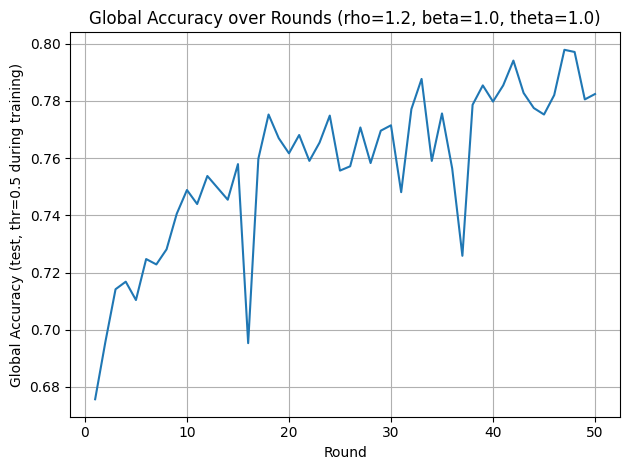

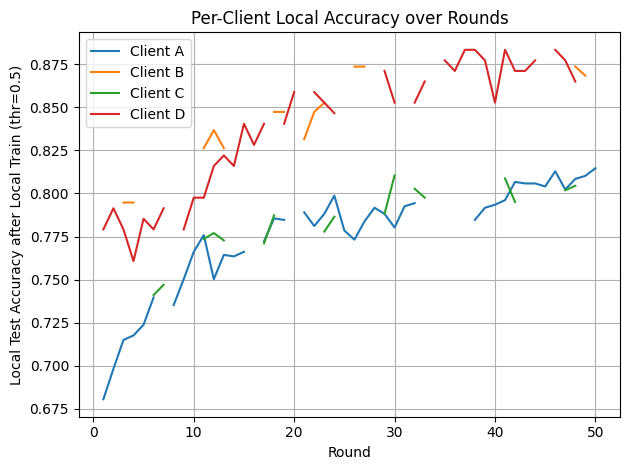

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation (n_i, c_i, t_i)
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation
# + Grid-search로 찾은 최적 하이퍼파라미터 (rho, beta, theta)=(1.2,1.0,1.0)
# + Round별 Global / Local Accuracy 로깅 & 시각화
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ------------------------------------------------
# 0) 재현성 & Defect 라벨 정의
# ------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# αᵢ 하이퍼파라미터 (Grid-search로 선정된 값)
RHO   = 1.2   # 데이터 수(n_i) 민감도
BETA  = 1.0   # 클래스 다양성(c_i) 민감도
THETA = 1.0   # 참여도(t_i) 민감도

# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    """SMOTE로 class 0/1 비율을 1:1에 가깝게 맞추는 함수 (양적 균형만 맞춤)."""
    sm = SMOTE(random_state=SEED, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    """
    - 엑셀에서 결측/무한/비수치 제거
    - DEFECT_LABELS 합쳐서 binary label (0: 정상, 1: 결함)
    - SMOTE로 oversampling
    """
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 결함 라벨 합쳐서 0/1 binary
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처: 수치형만 사용
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    """
    - 각 클라이언트별로: 엑셀 로드 → SMOTE → 공통 컬럼 교집합만 사용
    - 클라이언트 내부에서 평균0, 표준편차1로 표준화
    - 8:2 train/test split
    """
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 모든 클라이언트에서 공통으로 존재하는 feature만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()

        # 클라이언트별 Standardization
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)

        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test  = n - n_train

        tr, te = random_split(
            allset,
            [n_train, n_test],
            generator=torch.Generator().manual_seed(SEED)
        )

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)

# ------------------------------------------------
# 2) DeepMLP 모델 정의
# ------------------------------------------------
class DeepMLP(nn.Module):
    """
    입력: input_dim 차원 → 3개의 은닉층 (128-128-64) + Dropout + BN
    출력: binary classification (2 클래스)
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------
# 3) Focal Loss (불균형 학습 난이도 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    """
    alpha: 양/음성 가중 (여기서는 전체 scale factor)
    gamma: easy sample down-weighting 강도 (크면 어려운 샘플에 더 집중)
    """
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)  # 예측이 맞을수록 pt ↑
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# ------------------------------------------------
# 4) αᵢ 구성요소 및 FedBN Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    """
    c_i: 클라이언트 i의 label 다양성
    - H: Shannon entropy
    - logK: 가능한 클래스 수 (여기선 binary지만 일반형으로 유지)
    - k_i: 실제로 충분히 등장한 클래스 개수
    => c_i = (k_i/K) * (H_tilde / logK)
    """
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    # Shannon entropy
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK   # entropy가 너무 0에 가까워지지 않게 바닥값
    H_tilde = max(H, H_floor)

    # min_samples 이상 등장한 클래스만 카운트
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))

def aggregate_with_softmax_weights(state_dicts, alpha_components,
                                   rho=RHO, beta=BETA, theta=THETA,
                                   use_fedbn=True):
    """
    αᵢ = softmax( log(nᵢ^ρ) + log(cᵢ^β) + log(tᵢ^θ) )
    - nᵢ: 데이터 양 기반 (여기선 sqrt(n_samples))
    - cᵢ: label 다양성 (compute_ci)
    - tᵢ: 참여도 (participation_probs)
    FedBN-style:
      - BN 관련 파라미터는 클라이언트별로 유지 (Global aggregation에서 제외)
    """
    if not state_dicts:
        return None

    # 1) 로그 도메인에서 합산
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )

    # 2) softmax 정규화
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp  = sum(exp_logits.values())
    alphas     = {cid: exp_logits[cid] / total_exp for cid in logits}

    # 3) FedBN-style 모델 파라미터 집계
    base_sd  = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        # BatchNorm(혹은 running_mean/var) 는 개인화 유지
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()

    return global_sd

# ------------------------------------------------
# 5) Local Train (FedProx 적용)
# ------------------------------------------------
def local_train(base_model, dataset, lr, epochs, device,
                global_params=None, mu=0.0):
    """
    FedProx-style 로컬 학습:
      loss_local = FocalLoss + (mu/2) * ||w_local - w_global||^2
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    if mu > 0.0 and global_params is None:
        global_params = [p.detach().clone() for p in base_model.parameters()]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx term
            if mu > 0.0 and global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()

# ------------------------------------------------
# 6) 평가 함수 (threshold 적용)
# ------------------------------------------------
def evaluate(model, dataset, device, threshold=0.5, return_preds=False):
    """
    - softmax로 class 1 확률 뽑고
    - threshold 기준으로 0/1 결정
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=256)

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()

            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.30, 0.51, 0.05)):
    """
    여러 threshold에 대해 F1(binary) 확인 후 best threshold 선택
    """
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device,
                             threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1

    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t, best_f1

# ------------------------------------------------
# 7) Main Loop (연합학습 + 로깅 + 시각화)
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds",    type=int,   default=50)
    parser.add_argument("--mu",        type=float, default=0.003)  # FedProx 계수
    parser.add_argument("--ft_epochs", type=int,   default=5)      # per-client fine-tuning epoch
    args, _ = parser.parse_known_args()

    # 1) 클라이언트 데이터 로드
    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 입력 차원 잡기 (A 기준)
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim,
                           hidden_dim=128,
                           num_classes=2).to(device)

    # 참여 확률 (label-aware participation 이나 정책 기반 참여도 대체 가능)
    participation_probs = {"A": 0.9, "D": 0.7, "B": 0.4, "C": 0.4}

    # 전체 test set (global 평가용)
    combined_test = torch.utils.data.ConcatDataset(
        [v["test"] for v in clients.values()]
    )

    # 라운드별 로그
    global_acc_history = []            # round별 global accuracy
    local_acc_history  = {cid: [] for cid in clients.keys()}  # round별 local accuracy (참여 안 하면 NaN)

    rounds = args.rounds

    # 2) Federated Training Loop
    for rnd in range(1, rounds + 1):
        print(f"\n=== Round {rnd} (rho={RHO}, beta={BETA}, theta={THETA}) ===")

        # 참여 클라이언트 샘플링
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        print(f" Participating clients: {selected}")

        # aggregation 위한 dict들
        state_dicts      = {}
        alpha_components = {}

        # 라운드 시작 전 global accuracy
        before_acc = evaluate(global_model, combined_test, device, threshold=0.5)

        # FedProx용 global_params snapshot
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 모든 클라이언트에 대해 local_acc 기록용: 참여 안 한 경우 NaN
        for cid in clients.keys():
            local_acc_history[cid].append(float('nan'))

        # 로컬 학습
        for cid in selected:
            ds_train = clients[cid]["train"]

            # label 분포 계산 (c_i용)
            labels = [int(y) for _, y in ds_train]
            class_counts = pd.Series(labels).value_counts().to_dict()

            # local train
            state_dict = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = state_dict

            # αᵢ 구성요소: n_i, c_i, t_i
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]

            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

            # 현재 라운드에서 "local 모델" 성능도 기록
            temp_model = copy.deepcopy(global_model)
            temp_model.load_state_dict(state_dict)
            acc_local = evaluate(temp_model, clients[cid]["test"], device, threshold=0.5)
            local_acc_history[cid][-1] = acc_local
            print(f"  [Client {cid}] Local Test Accuracy (after local_train): {acc_local:.4f}")

        # FedBN-style Aggregation (FedAvg 가중치에 αᵢ 반영)
        new_global_sd = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO,
            beta=BETA,
            theta=THETA,
            use_fedbn=True
        )
        if new_global_sd is None:
            continue

        global_model.load_state_dict(new_global_sd)

        after_acc = evaluate(global_model, combined_test, device, threshold=0.5)
        global_acc_history.append(after_acc)
        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}")

    # ------------------------------------------------
    # 3) Global 최종 평가 + best threshold 탐색
    # ------------------------------------------------
    print("\n=== Global Evaluation (with Best Threshold Search) ===")
    best_t, best_f1 = find_best_threshold(global_model, combined_test, device)
    global_acc, yt, yp = evaluate(global_model, combined_test, device,
                                  threshold=best_t, return_preds=True)
    print(f"\n[Final Global] thr={best_t:.2f}, acc={global_acc:.4f}, f1={best_f1:.4f}")
    print(classification_report(yt, yp, digits=4))

    # ------------------------------------------------
    # 4) Per-Client Fine-tuning (Personalization)
    # ------------------------------------------------
    print("\n===============================")
    print(" Per-Client Fine-tuning (Personalization)")
    print("===============================")

    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        # global_model을 시작점으로 client별 추가 local epochs
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.0008,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,  # fine-tuning 시에는 FedProx term off(선택)
            mu=0.0
        )
        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(local_model, data["test"], device,
                                     threshold=best_t, return_preds=True)
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))

    # ------------------------------------------------
    # 5) 시각화: 라운드별 Global Accuracy & Local Accuracy
    # ------------------------------------------------
    rounds_axis = list(range(1, rounds + 1))

    # (1) Global Accuracy
    plt.figure()
    plt.plot(rounds_axis, global_acc_history)
    plt.xlabel("Round")
    plt.ylabel("Global Accuracy (test, thr=0.5 during training)")
    plt.title(f"Global Accuracy over Rounds (rho={RHO}, beta={BETA}, theta={THETA})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # (2) Local Accuracy per Client (참여한 라운드만 값, 나머지는 NaN)
    plt.figure()
    for cid in clients.keys():
        plt.plot(rounds_axis, local_acc_history[cid], label=f"Client {cid}")
    plt.xlabel("Round")
    plt.ylabel("Local Test Accuracy after Local Train (thr=0.5)")
    plt.title("Per-Client Local Accuracy over Rounds")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
